<a href="https://colab.research.google.com/github/GeraldL19/Final-Year-Project-2024/blob/main/Sentiment_analysis_trial_2023_09_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this first draft I use a cade used from the website datacamp

In order to test some simple sentiment analysis algorythm and understand the functionement.

I use this financial data of small opinion: https://www.kaggle.com/datasets/sbhatti/financial-sentiment-analysis?select=data.csv

And I use inspiration from  the following keras: https://www.kaggle.com/code/magedmahmoud/mastering-sentiment-analysis#Model-1



In [1]:
# import libraries
import pandas as pd

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
# nltk imports
from nltk.tokenize import word_tokenize  # tokenize the text == the text is splitted into words in list
from nltk.corpus import stopwords  # this contain common stop words that has no effect in analysis
from nltk.stem import WordNetLemmatizer  # Lemmatization is the process of grouping together the different inflected forms of a word so they can be analyzed as a single item

# download nltk corpus (first time only)
import nltk

nltk.download('all')



[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package basque_grammars to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping grammars/basque_grammars.zip.
[nltk_data]    | Downloading package bcp47 to /root/nltk_data...
[nltk_data]    | Downloading package biocreative_ppi to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   U

True

In [2]:
# Load the amazon review dataset
df = pd.read_csv('https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/amazon.csv')
df

,reviewText,Positive
0,This is a one of the best apps acording to a b...,1
1,This is a pretty good version of the game for ...,1
2,this is a really cool game. there are a bunch ...,1
3,"This is a silly game and can be frustrating, b...",1
4,This is a terrific game on any pad. Hrs of fun...,1
...,...,...
19995,this app is fricken stupid.it froze on the kin...,0
19996,Please add me!!!!! I need neighbors! Ginger101...,1
19997,love it! this game. is awesome. wish it had m...,1
19998,I love love love this app on my side of fashio...,1


Preparing the data for NLP processing using tokenization, lemmatization and stop word remover.

In [3]:
# create preprocess_text function
def preprocess_text(text):
    # Tokenize the text
    tokens = word_tokenize(text.lower())

    # Remove stop words
    filtered_tokens = [token for token in tokens if token not in stopwords.words('english')]

    # Lemmatize the tokens
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]

    # Join the tokens back into a string
    processed_text = ' '.join(lemmatized_tokens)
    return processed_text

# apply the function df
df['reviewText'] = df['reviewText'].apply(preprocess_text)
df

,reviewText,Positive
0,one best apps acording bunch people agree bomb...,1
1,pretty good version game free . lot different ...,1
2,really cool game . bunch level find golden egg...,1
3,"silly game frustrating , lot fun definitely re...",1
4,terrific game pad . hr fun . grandkids love . ...,1
...,...,...
19995,app fricken stupid.it froze kindle wont allow ...,0
19996,please add ! ! ! ! ! need neighbor ! ginger101...,1
19997,love ! game . awesome . wish free stuff house ...,1
19998,love love love app side fashion story fight wo...,1


Simple sentiment analysis function  with two outcome.

In [4]:
# initialize NLTK sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# create get_sentiment function
def get_sentiment(text):
    scores = analyzer.polarity_scores(text)
    sentiment = 1 if scores['pos'] > 0 else 0
    return sentiment

# apply get_sentiment function
df['sentiment'] = df['reviewText'].apply(get_sentiment)
df

,reviewText,Positive,sentiment
0,one best apps acording bunch people agree bomb...,1,1
1,pretty good version game free . lot different ...,1,1
2,really cool game . bunch level find golden egg...,1,1
3,"silly game frustrating , lot fun definitely re...",1,1
4,terrific game pad . hr fun . grandkids love . ...,1,1
...,...,...,...
19995,app fricken stupid.it froze kindle wont allow ...,0,0
19996,please add ! ! ! ! ! need neighbor ! ginger101...,1,1
19997,love ! game . awesome . wish free stuff house ...,1,1
19998,love love love app side fashion story fight wo...,1,1


In [5]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(df['Positive'], df['sentiment']))

[[ 1131  3636]
 [  576 14657]]


In [6]:
from sklearn.metrics import classification_report
print(classification_report(df['Positive'], df['sentiment']))

              precision    recall  f1-score   support

           0       0.66      0.24      0.35      4767
           1       0.80      0.96      0.87     15233

    accuracy                           0.79     20000
   macro avg       0.73      0.60      0.61     20000
weighted avg       0.77      0.79      0.75     20000



Using the 'Financial Sentiment 1' dataset from kaggle.

In [7]:
# Load the financial sentiment dataset
df = pd.read_csv('Financial Sentiement 1.csv')
df

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral
...,...,...
5837,RISING costs have forced packaging producer Hu...,negative
5838,Nordic Walking was first used as a summer trai...,neutral
5839,"According shipping company Viking Line , the E...",neutral
5840,"In the building and home improvement trade , s...",neutral


In [8]:
df.shape

(5842, 2)

In [9]:
unique_sentiments = df.Sentiment.unique()
unique_sentiments

array(['positive', 'negative', 'neutral'], dtype=object)

<Axes: >

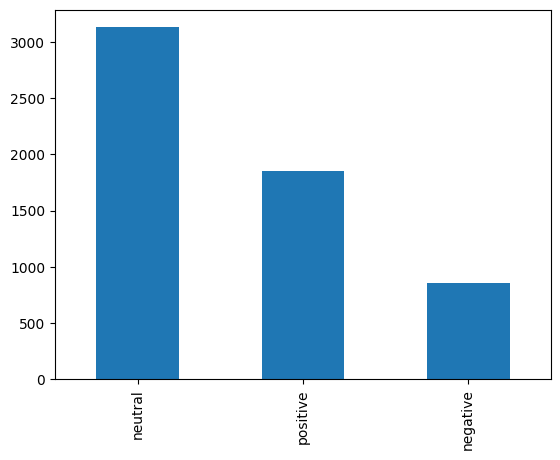

In [10]:
df.Sentiment.value_counts().plot.bar()

In [11]:
# mapping to the sentiment column i.e. replacing words (postive) with numbers (1)
dicto = {'positive': 1, 'neutral': 0 , 'negative': -1}
df.Sentiment = df.Sentiment.map(dicto)

Same pre-processing process as before.

In [12]:
# create preprocess_text function
def preprocess_text(text):
    # Tokenize the text
    tokens = word_tokenize(text.lower())

    # Remove stop words
    filtered_tokens = [token for token in tokens if token not in stopwords.words('english')]

    # Lemmatize the tokens
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]

    # Join the tokens back into a string
    processed_text = ' '.join(lemmatized_tokens)
    return processed_text

# apply the function df
df['Sentence'] = df['Sentence'].apply(preprocess_text)
df

,Sentence,Sentiment
0,geosolutions technology leverage benefon 's gp...,1
1,"$ esi low , $ 1.50 $ 2.50 bk real possibility",-1
2,"last quarter 2010 , componenta 's net sale dou...",1
3,"according finnish-russian chamber commerce , m...",0
4,swedish buyout firm sold remaining 22.4 percen...,0
...,...,...
5837,rising cost forced packaging producer huhtamak...,-1
5838,nordic walking first used summer training meth...,0
5839,"according shipping company viking line , eu de...",0
5840,"building home improvement trade , sale decreas...",0


https://www.analyticsvidhya.com/blog/2021/07/performing-sentiment-analysis-with-naive-bayes-classifier/

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [14]:
# Split into training and testing data
x = df['Sentence']
y = df['Sentiment']
x, x_test, y, y_test = train_test_split(x,y, stratify=y, test_size=0.3, random_state=42)

In [15]:
# Vectorize text reviews to numbers
vec = CountVectorizer(stop_words='english')
x = vec.fit_transform(x).toarray()
x_test = vec.transform(x_test).toarray()

In [16]:
model = MultinomialNB()
model.fit(x, y)

MultinomialNB()

In [17]:
model.score(x_test, y_test)

0.6742726754135767

Another test using different types of naive bayes models.
Code from :https://medium.com/@tpreethi/undesrtand-naive-bayes-algorithm-in-simple-explanation-with-python-code-part-2-a2b91cbbf637

Multinomial Bayes is still the best performing model

In [18]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score# Naive Bayes Classifiers
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()# fitting and predicting
gnb.fit(x, y)
y_pred_gnb = gnb.predict(x_test)
mnb.fit(x, y)
y_pred_mnb = mnb.predict(x_test)
bnb.fit(x, y)
y_pred_bnb = bnb.predict(x_test)# accuracy scores
print("Gaussian", accuracy_score(y_test, y_pred_gnb))
print("Multinomial", accuracy_score(y_test, y_pred_mnb))
print("Bernoulli", accuracy_score(y_test, y_pred_bnb))

Gaussian 0.511123787792356
Multinomial 0.6742726754135767
Bernoulli 0.6617227609811751


In [19]:
y_pred = model.predict(x_test)
accuracy_score(y_pred, y_test)

0.6742726754135767

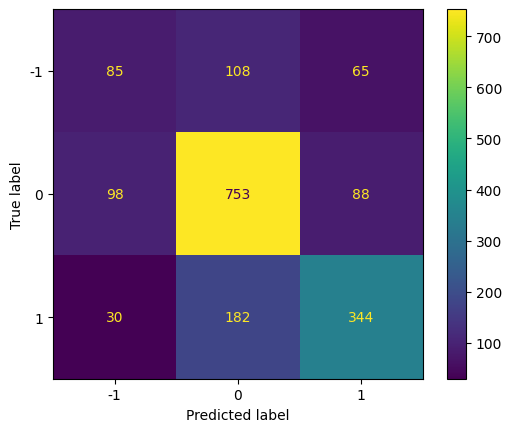

In [20]:
labels = [-1,0,1]
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot();

Second financial datasets from kaggle: https://www.kaggle.com/datasets/ankurzing/sentiment-analysis-for-financial-news

Data set called 'Financial Phrase Bank'


In [21]:
# Load the financial sentiment dataset
df2 = pd.read_csv('Financial Phrase Bank.csv', encoding='latin-1')
df2

,phrase,sentiment
0,"According to Gran , the company has no plans t...",neutral
1,Technopolis plans to develop in stages an area...,neutral
2,The international electronic industry company ...,negative
3,With the new production plant the company woul...,positive
4,According to the company 's updated strategy f...,positive
...,...,...
4841,LONDON MarketWatch -- Share prices ended lower...,negative
4842,Rinkuskiai 's beer sales fell by 6.5 per cent ...,neutral
4843,Operating profit fell to EUR 35.4 mn from EUR ...,negative
4844,Net sales of the Paper segment decreased to EU...,negative


In [22]:
df2.shape

(4846, 2)

In [23]:
unique_sentiments = df2.sentiment.unique()
unique_sentiments

array(['neutral', 'negative', 'positive'], dtype=object)

<Axes: >

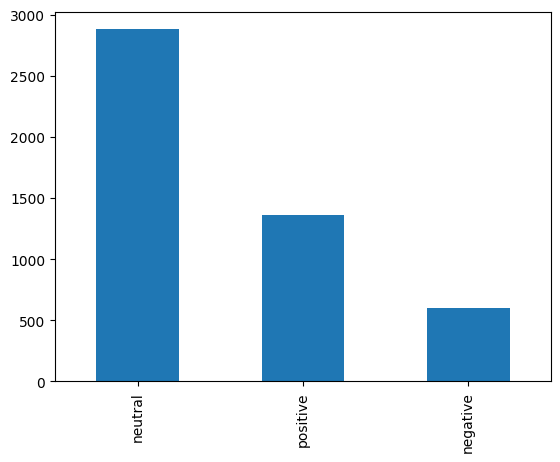

In [24]:
df2.sentiment.value_counts().plot.bar()

In [25]:
# mapping to the sentiment column i.e. replacing words (postive) with numbers (1)
dicto = {'positive': 1, 'neutral': 0 , 'negative': -1}
df2.sentiment = df2.sentiment.map(dicto)

In [26]:
# apply the function df
df2['phrase'] = df2['phrase'].apply(preprocess_text)
df2

,phrase,sentiment
0,"according gran , company plan move production ...",0
1,"technopolis plan develop stage area le 100,000...",0
2,international electronic industry company elco...,-1
3,new production plant company would increase ca...,1
4,according company 's updated strategy year 200...,1
...,...,...
4841,london marketwatch -- share price ended lower ...,-1
4842,rinkuskiai 's beer sale fell 6.5 per cent 4.16...,0
4843,operating profit fell eur 35.4 mn eur 68.8 mn ...,-1
4844,net sale paper segment decreased eur 221.6 mn ...,-1


In [27]:
# Split into training and testing data
x2 = df2['phrase']
y2 = df2['sentiment']
x2, x_test2, y2, y_test2 = train_test_split(x2,y2, stratify=y2, test_size=0.3, random_state=42)

# Vectorize text reviews to numbers
vec2 = CountVectorizer(stop_words='english')
x2 = vec2.fit_transform(x2).toarray()
x_test2 = vec2.transform(x_test2).toarray()

In [28]:
model2 = MultinomialNB()
model2.fit(x2, y2)

MultinomialNB()

In [29]:
gnb.fit(x2, y2)
y_pred_gnb2 = gnb.predict(x_test2)
mnb.fit(x2, y2)
y_pred_mnb2 = mnb.predict(x_test2)
bnb.fit(x2, y2)
y_pred_bnb2 = bnb.predict(x_test2)
# accuracy scores
print("Gaussian", accuracy_score(y_test2, y_pred_gnb2))
print("Multinomial", accuracy_score(y_test2, y_pred_mnb2))
print("Bernoulli", accuracy_score(y_test2, y_pred_bnb2))

Gaussian 0.5495185694635488
Multinomial 0.6932599724896836
Bernoulli 0.6815680880330124


In [30]:
y_pred2 = model2.predict(x_test2)
accuracy_score(y_pred2, y_test2)

0.6932599724896836

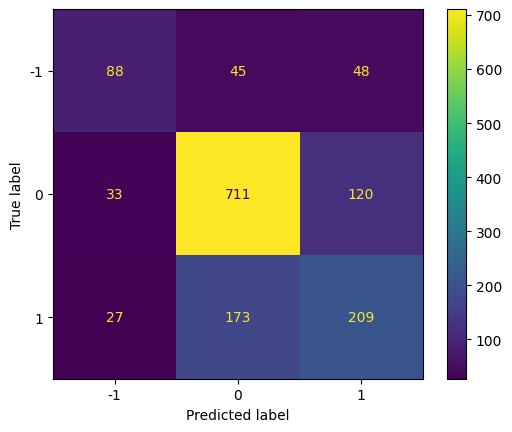

In [31]:
labels2 = [-1,0,1]
cm2 = confusion_matrix(y_test2, y_pred2, labels=labels2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=labels2)
disp2.plot();